# Skin Lesion Classification — Deep Learning Project
## Section 12 — Final Project Report
**Dataset:** HAM10000 | **Models:** Custom CNN vs MobileNetV2 | **Task:** Multi-class Classification

---
### Pipeline Overview
1. Setup & Data Download
2. Exploratory Data Analysis (EDA)
3. Preprocessing
4. Model 1 — Custom CNN
5. Model 2 — MobileNetV2 (Transfer Learning)
6. Evaluation & Comparison
7. Results & Visualizations

## 1. Setup & Installations

In [3]:
# Install dependencies
!pip install kaggle tensorflow scikit-learn matplotlib seaborn pandas numpy Pillow -q

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.preprocessing import LabelEncoder

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.20.0
GPU available: True


## 2. Dataset Download (HAM10000 from Kaggle)

> **Instructions:** Upload your `kaggle.json` API key file first, OR manually download the dataset from:
> https://www.kaggle.com/datasets/kmader/skin-lesion-analysis-toward-melanoma-detection
> and upload the zip to Colab.

In [4]:
import os

# Upload kaggle.json
from google.colab import files
uploaded = files.upload()

# Récupère le bon nom de fichier (même si renommé)
json_file = list(uploaded.keys())[0]

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
os.rename(json_file, os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

# Vérifie que ça fonctionne
!kaggle datasets list --search ham10000

!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip -q skin-cancer-mnist-ham10000.zip -d /content/ham10000

Saving kaggle.json to kaggle (2).json
ref                                                          title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  -----------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
kmader/skin-cancer-mnist-ham10000                            Skin Cancer MNIST: HAM10000                       5582914511  2018-09-20 20:36:13.037000         267769       2348  0.7058824        
surajghuwalewala/ham1000-segmentation-and-classification     Skin cancer: HAM10000                             2781385274  2021-05-27 09:08:46.813000          20280        150  0.9411765        
tschandl/ham10000-lesion-segmentations                       HAM10000 Lesion Segmentations                       10766207  2020-07-02 21:20:22.710000           3070         35  0.875

In [5]:
BASE_DIR = '/content/ham10000'
metadata_path = os.path.join(BASE_DIR, 'HAM10000_metadata.csv')

# Les images sont dans ces 4 dossiers (doublons majuscules/minuscules)
img_dirs = [
    os.path.join(BASE_DIR, 'HAM10000_images_part_1'),
    os.path.join(BASE_DIR, 'HAM10000_images_part_2'),
    os.path.join(BASE_DIR, 'ham10000_images_part_1'),
    os.path.join(BASE_DIR, 'ham10000_images_part_2'),
]

# Vérification
for d in img_dirs:
    count = len(os.listdir(d)) if os.path.exists(d) else 0
    print(f'{d}: {count} images')

/content/ham10000/HAM10000_images_part_1: 5000 images
/content/ham10000/HAM10000_images_part_2: 5015 images
/content/ham10000/ham10000_images_part_1: 5000 images
/content/ham10000/ham10000_images_part_2: 5015 images


## 3. Exploratory Data Analysis (EDA)

In [6]:
# Load metadata
# Adjust path based on your directory structure
metadata_path = os.path.join(BASE_DIR, 'HAM10000_metadata.csv')
df = pd.read_csv(metadata_path)

print('Dataset shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Dataset shape: (10015, 7)

Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

First 5 rows:


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


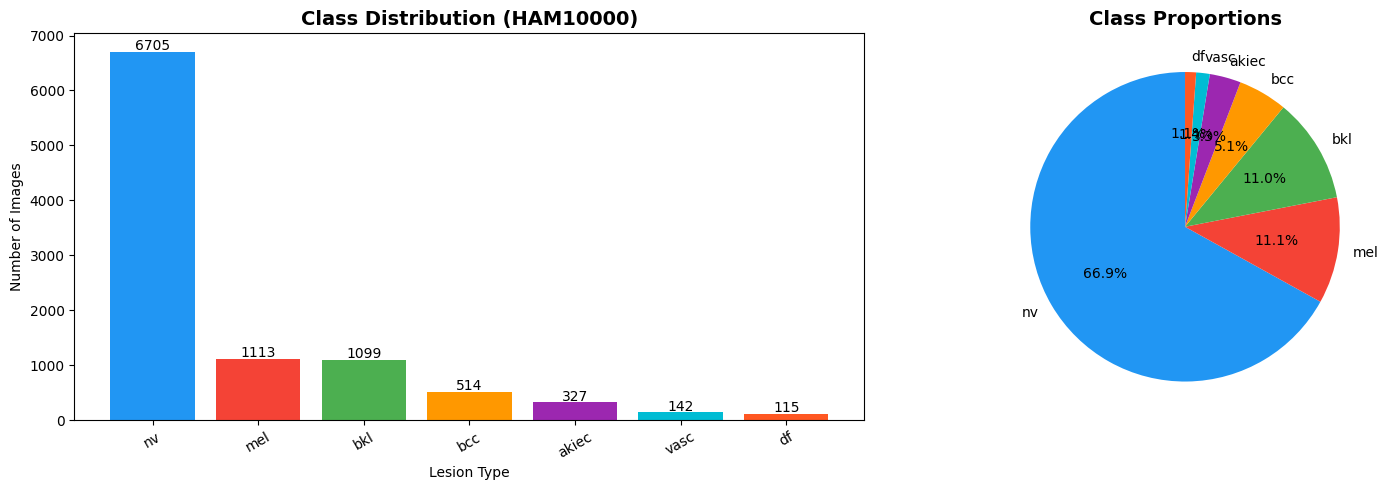

Figure saved: class_distribution.png


In [7]:
# Class distribution
print('Class distribution:')
print(df['dx'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Count plot
class_counts = df['dx'].value_counts()
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4', '#FF5722']
axes[0].bar(class_counts.index, class_counts.values, color=colors)
axes[0].set_title('Class Distribution (HAM10000)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lesion Type')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=30)
for i, (idx, val) in enumerate(class_counts.items()):
    axes[0].text(i, val + 30, str(val), ha='center', fontsize=10)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Class Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: class_distribution.png')

Missing values per column:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


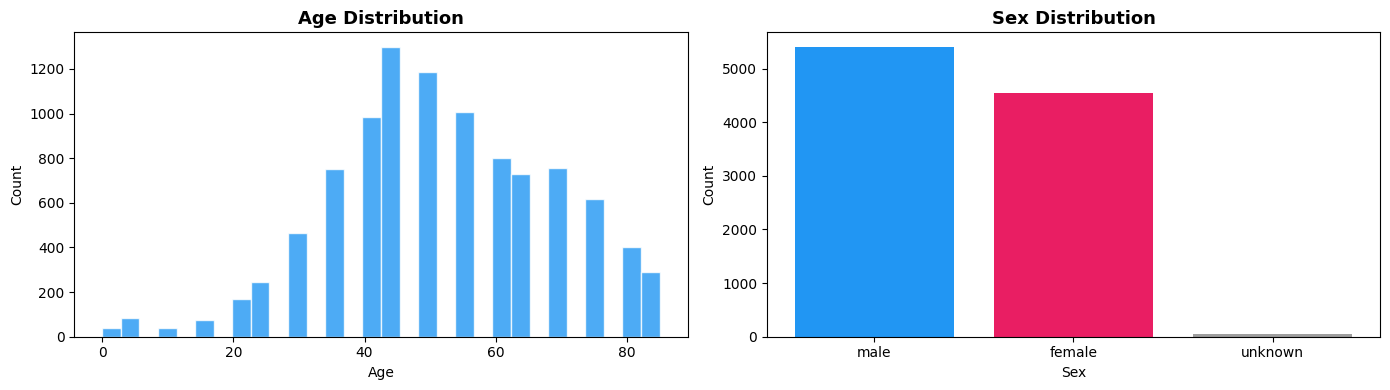

In [8]:
# Missing values analysis
print('Missing values per column:')
print(df.isnull().sum())

# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['age'].dropna(), bins=30, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].set_title('Age Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

sex_counts = df['sex'].value_counts()
axes[1].bar(sex_counts.index, sex_counts.values, color=['#2196F3', '#E91E63', '#9E9E9E'])
axes[1].set_title('Sex Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('metadata_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

##  4. Preprocessing

In [9]:
# STEP 1: Handle Missing Values

# Age: fill with median per class (more clinically meaningful)
df['age'] = df.groupby('dx')['age'].transform(lambda x: x.fillna(x.median()))

# Sex: fill with mode
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])

print('Missing values after imputation:')
print(df.isnull().sum())
print(f'\nAge imputed using per-class median.')
print(f'Sex imputed using global mode: {df["sex"].mode()[0]}')

Missing values after imputation:
lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64

Age imputed using per-class median.
Sex imputed using global mode: male


In [10]:
# STEP 2: Build image path column

# HAM10000 comes in two image folders
img_dir_1 = os.path.join(BASE_DIR, 'HAM10000_images_part_1')
img_dir_2 = os.path.join(BASE_DIR, 'HAM10000_images_part_2')

def find_image_path(img_id):
    for folder in [img_dir_1, img_dir_2]:
        path = os.path.join(folder, f'{img_id}.jpg')
        if os.path.exists(path):
            return path
    return None

df['path'] = df['image_id'].apply(find_image_path)
df = df[df['path'].notna()].reset_index(drop=True)
print(f'Images found: {len(df)}')

# Label encoding
le = LabelEncoder()
df['label'] = le.fit_transform(df['dx'])
class_names = le.classes_
n_classes = len(class_names)

print(f'\nClass mapping:')
for i, cls in enumerate(class_names):
    print(f'  {i}: {cls}')

Images found: 10015

Class mapping:
  0: akiec
  1: bcc
  2: bkl
  3: df
  4: mel
  5: nv
  6: vasc


In [11]:
# STEP 3: Load & Resize Images

IMG_SIZE_CNN = 64    # for custom CNN
IMG_SIZE_MOB = 224   # for MobileNetV2

def load_images(df, img_size, max_samples=None):
    """Load images from disk, resize, and normalize to [0,1]."""
    if max_samples:
        df = df.sample(min(max_samples, len(df)), random_state=SEED)
    images = []
    labels = []
    for _, row in df.iterrows():
        try:
            img = Image.open(row['path']).convert('RGB')
            img = img.resize((img_size, img_size))
            images.append(np.array(img) / 255.0)  # Min-Max normalization
            labels.append(row['label'])
        except Exception as e:
            print(f'Error loading {row["path"]}: {e}')
    return np.array(images, dtype=np.float32), np.array(labels)

print('Loading images for CNN (64x64)...')
X_cnn, y = load_images(df, IMG_SIZE_CNN)
print(f'Loaded: {X_cnn.shape}, Labels: {y.shape}')

Loading images for CNN (64x64)...
Loaded: (10015, 64, 64, 3), Labels: (10015,)


In [12]:
# STEP 4: Train/Val/Test Split (Stratified)

y_cat = to_categorical(y, num_classes=n_classes)

# 70/15/15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_cnn, y_cat, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp.argmax(axis=1)
)

print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')

# Augmentation for training
datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)
datagen.fit(X_train)
print('\nData augmentation configured:')
print('  - Horizontal/Vertical flip')
print('  - Rotation: ±20°')
print('  - Zoom: ±15%')
print('  - Width/Height shift: ±10%')

Train: 7010 | Val: 1502 | Test: 1503

Data augmentation configured:
  - Horizontal/Vertical flip
  - Rotation: ±20°
  - Zoom: ±15%
  - Width/Height shift: ±10%


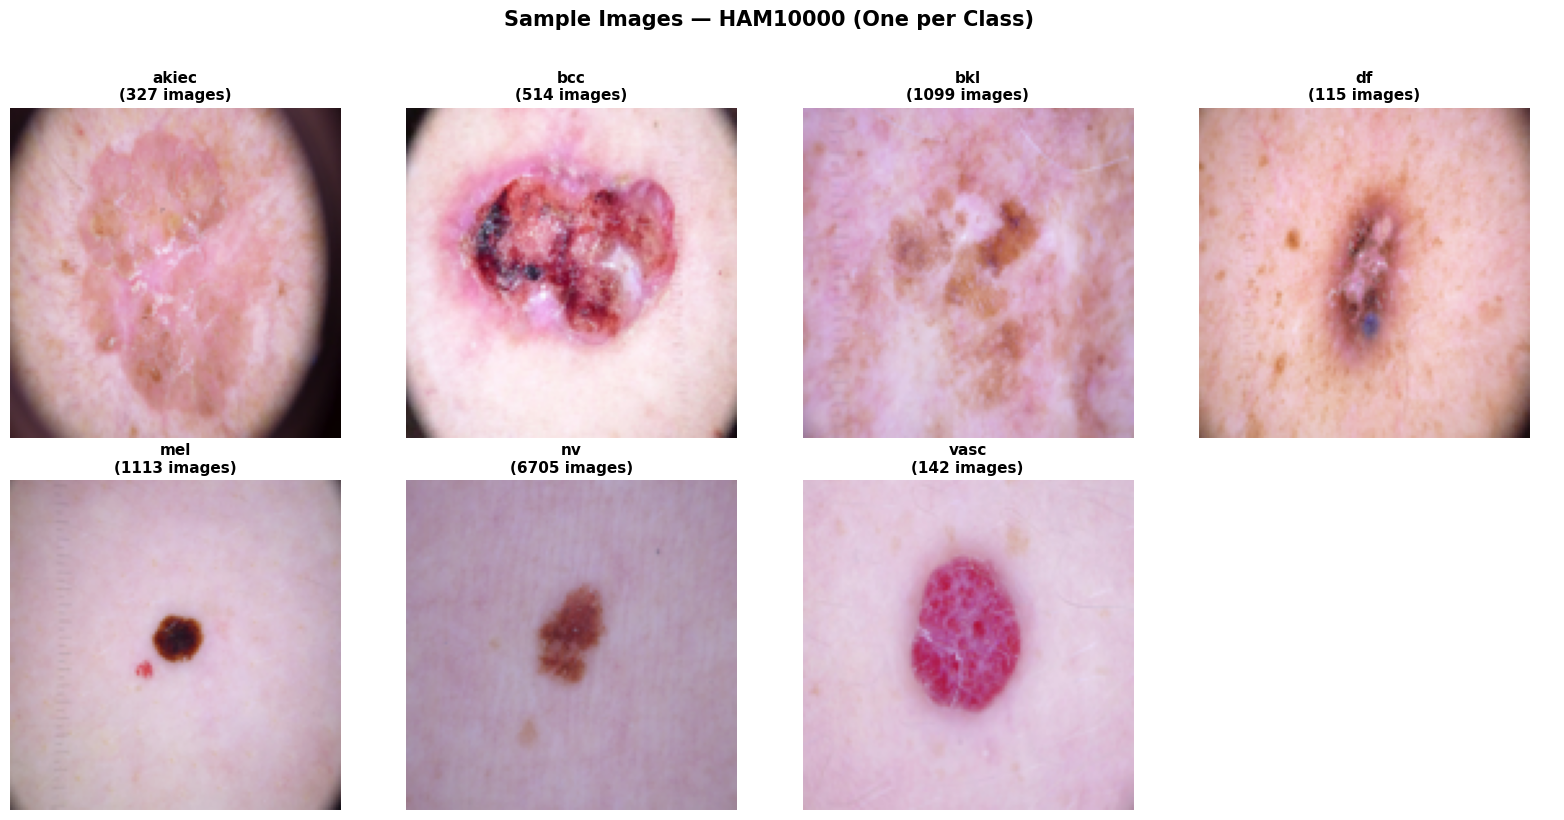

In [13]:
# Visualize sample images per class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, cls in enumerate(class_names[:7]):
    idx = df[df['dx'] == cls].index[0]
    img = Image.open(df.loc[idx, 'path']).convert('RGB').resize((128, 128))
    axes[i].imshow(img)
    axes[i].set_title(f'{cls}\n({df[df["dx"]==cls].shape[0]} images)', fontsize=11, fontweight='bold')
    axes[i].axis('off')

axes[7].axis('off')
plt.suptitle('Sample Images — HAM10000 (One per Class)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

##  5. Model 1 — Custom CNN

In [14]:
def build_custom_cnn(input_shape=(64, 64, 3), n_classes=7):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 4
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        # Classifier
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(n_classes, activation='softmax')
    ], name='Custom_CNN')
    return model

cnn_model = build_custom_cnn(input_shape=(64, 64, 3), n_classes=n_classes)
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,927 (1.75 MB)

 Trainable params: 456,967 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [15]:
# Train Custom CNN
callbacks_cnn = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss', verbose=1),
    ModelCheckpoint('best_cnn.keras', save_best_only=True, monitor='val_accuracy', verbose=0)
]

BATCH_SIZE = 32
EPOCHS_CNN = 30

history_cnn = cnn_model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED),
    epochs=EPOCHS_CNN,
    validation_data=(X_val, y_val),
    callbacks=callbacks_cnn,
    verbose=1
)
print('\nCNN Training complete!')

Epoch 1/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 26s 74ms/step - accuracy: 0.6645 - loss: 0.9494 - val_accuracy: 0.5506 - val_loss: 1.7248 - learning_rate: 0.0010
Epoch 2/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.7091 - loss: 0.8054 - val_accuracy: 0.4481 - val_loss: 2.0720 - learning_rate: 0.0010
Epoch 3/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.7121 - loss: 0.7633 - val_accuracy: 0.6711 - val_loss: 0.9851 - learning_rate: 0.0010
Epoch 4/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.7233 - loss: 0.7323 - val_accuracy: 0.5533 - val_loss: 1.1007 - learning_rate: 0.0010
Epoch 5/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.7324 - loss: 0.7174 - val_accuracy: 0.6778 - val_loss: 1.4801 - learning_rate: 0.0010
Epoch 6/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.7397 - loss: 0.6963 - val_accuracy: 0.7257 - val_loss: 0.7626 - learning_rate: 0.0010
Epoch 7/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.7368 - l

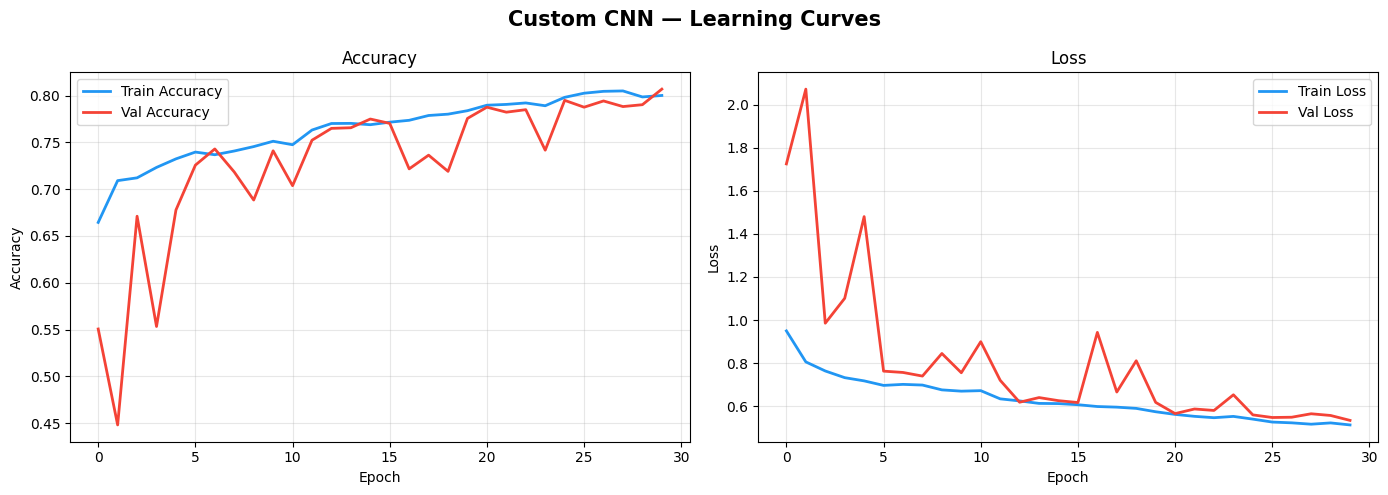

In [16]:
# Plot CNN Learning Curves

def plot_history(history, model_name, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} — Learning Curves', fontsize=15, fontweight='bold')

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='#2196F3', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='#F44336', linewidth=2)
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss', color='#2196F3', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss', color='#F44336', linewidth=2)
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_cnn, 'Custom CNN', save_path='cnn_learning_curves.png')

##  6. Model 2 — MobileNetV2 (Transfer Learning)

In [17]:
# ─── Load images for MobileNetV2 at 96x96 (saves RAM on Colab free tier) ───
IMG_SIZE_MOB = 96  # Reduced from 224 to avoid RAM crash

print('Loading images for MobileNetV2 (96x96)...')
X_mob, y_mob = load_images(df, IMG_SIZE_MOB)
y_mob_cat = to_categorical(y_mob, num_classes=n_classes)

# Same 70/15/15 stratified split as CNN
X_mob_train, X_mob_temp, y_mob_train, y_mob_temp = train_test_split(
    X_mob, y_mob_cat, test_size=0.30, random_state=SEED, stratify=y_mob
)
X_mob_val, X_mob_test, y_mob_val, y_mob_test = train_test_split(
    X_mob_temp, y_mob_temp, test_size=0.50, random_state=SEED,
    stratify=y_mob_temp.argmax(axis=1)
)
print(f'MobileNetV2 split — Train: {X_mob_train.shape[0]} | Val: {X_mob_val.shape[0]} | Test: {X_mob_test.shape[0]}')

Loading images for MobileNetV2 (96x96)...
MobileNetV2 split — Train: 7010 | Val: 1502 | Test: 1503


In [20]:
def build_mobilenetv2(n_classes=7):
    base_model = MobileNetV2(
        input_shape=(96, 96, 3),  # Reduced from 224 to save RAM
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Phase 1: freeze base layers

    inputs = keras.Input(shape=(96, 96, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='MobileNetV2_Transfer')
    return model, base_model

# Build and compile the model
mob_model, base = build_mobilenetv2(n_classes=n_classes)
mob_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
mob_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [21]:
# Phase 1: Feature Extraction (base frozen)
datagen_mob = ImageDataGenerator(
    horizontal_flip=True, vertical_flip=True,
    rotation_range=20, zoom_range=0.15,
    width_shift_range=0.1, height_shift_range=0.1
)
datagen_mob.fit(X_mob_train)

callbacks_mob = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=2, monitor='val_loss'),
    ModelCheckpoint('best_mobilenet.keras', save_best_only=True, monitor='val_accuracy')
]

print('Phase 1: Feature extraction (base frozen)...')
history_mob_1 = mob_model.fit(
    datagen_mob.flow(X_mob_train, y_mob_train, batch_size=32, seed=SEED),
    epochs=10,
    validation_data=(X_mob_val, y_mob_val),
    callbacks=callbacks_mob,
    verbose=1
)
print('Phase 1 complete!')

Phase 1: Feature extraction (base frozen)...
Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 70s 229ms/step - accuracy: 0.6766 - loss: 0.9587 - val_accuracy: 0.7064 - val_loss: 0.8132 - learning_rate: 0.0010
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - accuracy: 0.7006 - loss: 0.8325 - val_accuracy: 0.7250 - val_loss: 0.7758 - learning_rate: 0.0010
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.7184 - loss: 0.8012 - val_accuracy: 0.7417 - val_loss: 0.7574 - learning_rate: 0.0010
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - accuracy: 0.7183 - loss: 0.7827 - val_accuracy: 0.7091 - val_loss: 0.7973 - learning_rate: 0.0010
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - accuracy: 0.7240 - loss: 0.7653 - val_accuracy: 0.7184 - val_loss: 0.7718 - learning_rate: 0.0010
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - accuracy: 0.7358 - loss: 0.7307 - val_accuracy: 0.7317 - val_loss: 0.7506 - learning_rate: 5.0000e-04
Epoch 7/10
220/220 ━━━━━━━

In [22]:
# Phase 2: Fine-tuning (last 30 layers unfrozen)
base.trainable = True

# Freeze all layers except the last 30
for layer in base.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in mob_model.layers if l.trainable)
print(f'Trainable layers after unfreezing: {trainable_count}')

mob_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # Very low LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Phase 2: Fine-tuning (last 30 layers)...')
history_mob_2 = mob_model.fit(
    datagen_mob.flow(X_mob_train, y_mob_train, batch_size=32, seed=SEED),
    epochs=20,
    validation_data=(X_mob_val, y_mob_val),
    callbacks=callbacks_mob,
    verbose=1
)
print('Phase 2 complete!')

Trainable layers after unfreezing: 6
Phase 2: Fine-tuning (last 30 layers)...
Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 54s 162ms/step - accuracy: 0.6706 - loss: 0.9749 - val_accuracy: 0.7310 - val_loss: 0.7672 - learning_rate: 1.0000e-05
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.6936 - loss: 0.8925 - val_accuracy: 0.7324 - val_loss: 0.7774 - learning_rate: 1.0000e-05
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - accuracy: 0.7044 - loss: 0.8494 - val_accuracy: 0.7310 - val_loss: 0.7660 - learning_rate: 5.0000e-06
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.7054 - loss: 0.8423 - val_accuracy: 0.7337 - val_loss: 0.7577 - learning_rate: 5.0000e-06
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.7163 - loss: 0.8162 - val_accuracy: 0.7357 - val_loss: 0.7576 - learning_rate: 2.5000e-06
Phase 2 complete!


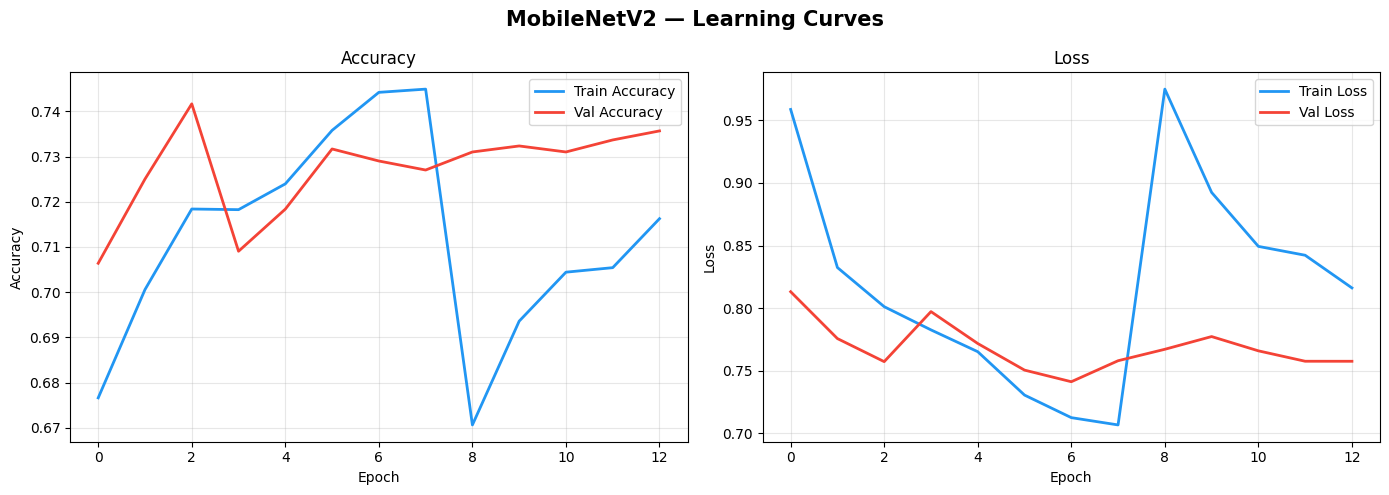

In [23]:
# Combine histories and plot
import collections

class CombinedHistory:
    def __init__(self, h1, h2):
        self.history = {}
        for key in h1.history:
            self.history[key] = h1.history[key] + h2.history[key]

history_mob = CombinedHistory(history_mob_1, history_mob_2)
plot_history(history_mob, 'MobileNetV2', save_path='mobilenet_learning_curves.png')

##  7. Evaluation & Results


  Custom CNN — Evaluation Results
  Overall Accuracy : 0.7997 (79.97%)
  Macro F1-Score   : 0.6071
              precision    recall  f1-score   support

       akiec      0.452     0.571     0.505        49
         bcc      0.641     0.649     0.645        77
         bkl      0.579     0.533     0.555       165
          df      0.429     0.176     0.250        17
         mel      0.612     0.443     0.514       167
          nv      0.884     0.936     0.909      1006
        vasc      1.000     0.773     0.872        22

    accuracy                          0.800      1503
   macro avg      0.656     0.583     0.607      1503
weighted avg      0.790     0.800     0.792      1503



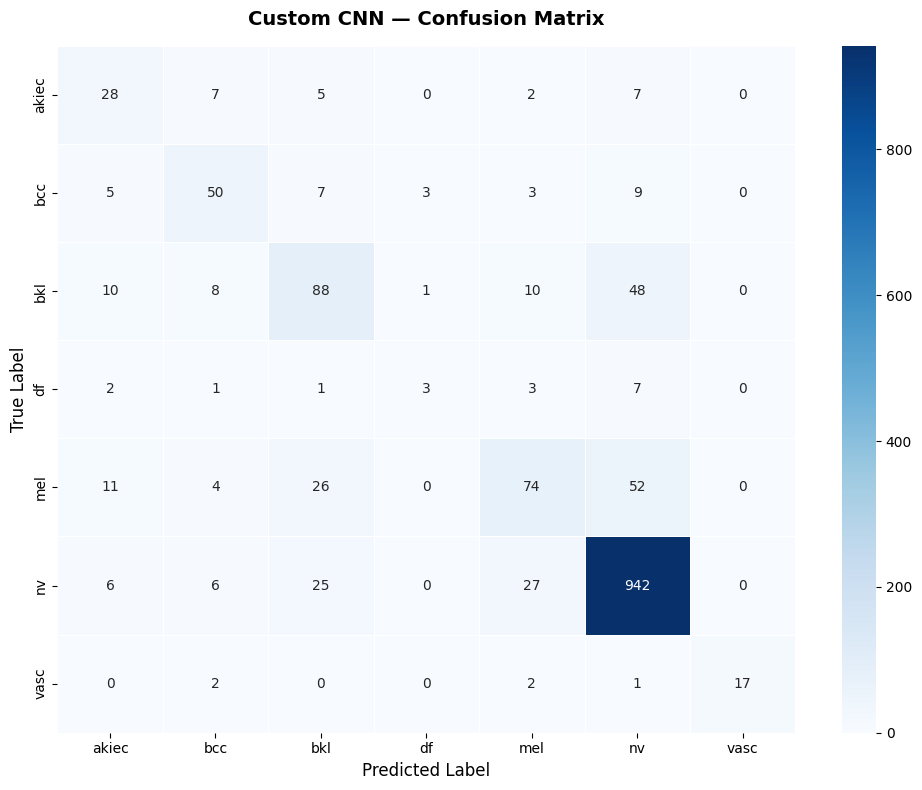

Confusion matrix saved: confusion_matrix_custom_cnn.png


In [24]:
def evaluate_model(model, X_test, y_test, class_names, model_name):
    """Full evaluation: accuracy, classification report, confusion matrix."""
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = y_pred_proba.argmax(axis=1)
    y_true = y_test.argmax(axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')

    print(f'\n{'='*60}')
    print(f'  {model_name} — Evaluation Results')
    print(f'{'='*60}')
    print(f'  Overall Accuracy : {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Macro F1-Score   : {f1:.4f}')
    print(f'{'='*60}')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5)
    plt.title(f'{model_name} — Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    save_name = f'confusion_matrix_{model_name.lower().replace(" ","_")}.png'
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Confusion matrix saved: {save_name}')

    return {'accuracy': acc, 'f1': f1, 'y_pred': y_pred, 'y_true': y_true}

# Evaluate CNN
cnn_results = evaluate_model(cnn_model, X_test, y_test, class_names, 'Custom CNN')


  MobileNetV2 — Evaluation Results
  Overall Accuracy : 0.7392 (73.92%)
  Macro F1-Score   : 0.3453
              precision    recall  f1-score   support

       akiec      0.000     0.000     0.000        49
         bcc      0.640     0.208     0.314        77
         bkl      0.422     0.394     0.408       165
          df      0.000     0.000     0.000        17
         mel      0.517     0.269     0.354       167
          nv      0.796     0.972     0.875      1006
        vasc      0.875     0.318     0.467        22

    accuracy                          0.739      1503
   macro avg      0.464     0.309     0.345      1503
weighted avg      0.682     0.739     0.693      1503



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


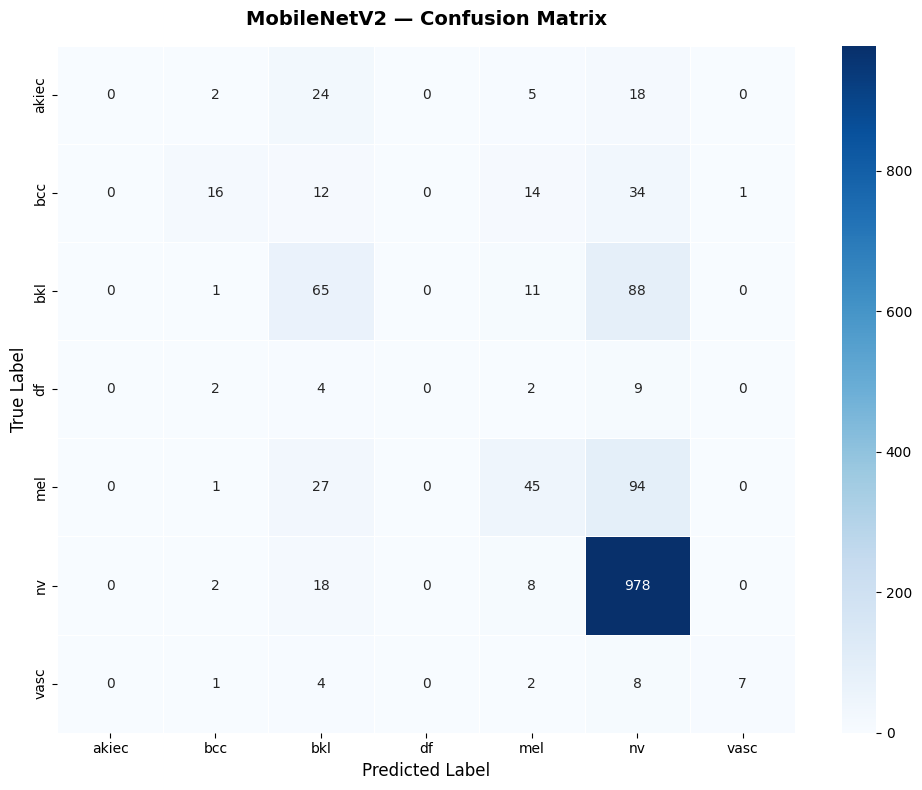

Confusion matrix saved: confusion_matrix_mobilenetv2.png


In [25]:
# Evaluate MobileNetV2
mob_results = evaluate_model(mob_model, X_mob_test, y_mob_test, class_names, 'MobileNetV2')

##  8. Scenario 3 — Comparison of All Methods

In [26]:
# Baseline: Logistic Regression on flattened pixels
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score as sk_f1

X_flat_train = X_train.reshape(X_train.shape[0], -1)
X_flat_test  = X_test.reshape(X_test.shape[0], -1)
y_train_1d   = y_train.argmax(axis=1)
y_test_1d    = y_test.argmax(axis=1)

print('Training Logistic Regression baseline...')
lr = LogisticRegression(max_iter=300, random_state=SEED, n_jobs=-1)
lr.fit(X_flat_train, y_train_1d)

y_lr_pred = lr.predict(X_flat_test)
lr_acc = accuracy_score(y_test_1d, y_lr_pred)
lr_f1  = sk_f1(y_test_1d, y_lr_pred, average='macro')
print(f'Logistic Regression — Accuracy: {lr_acc:.4f} | Macro F1: {lr_f1:.4f}')

Training Logistic Regression baseline...
Logistic Regression — Accuracy: 0.6906 | Macro F1: 0.3671



📊 FINAL COMPARISON:
                Method Accuracy Macro F1                     Type
   Logistic Regression    69.1%    0.367                 Baseline
            Custom CNN    80.0%    0.607  Deep Learning (scratch)
MobileNetV2 (Transfer)    73.9%    0.345 Deep Learning (transfer)


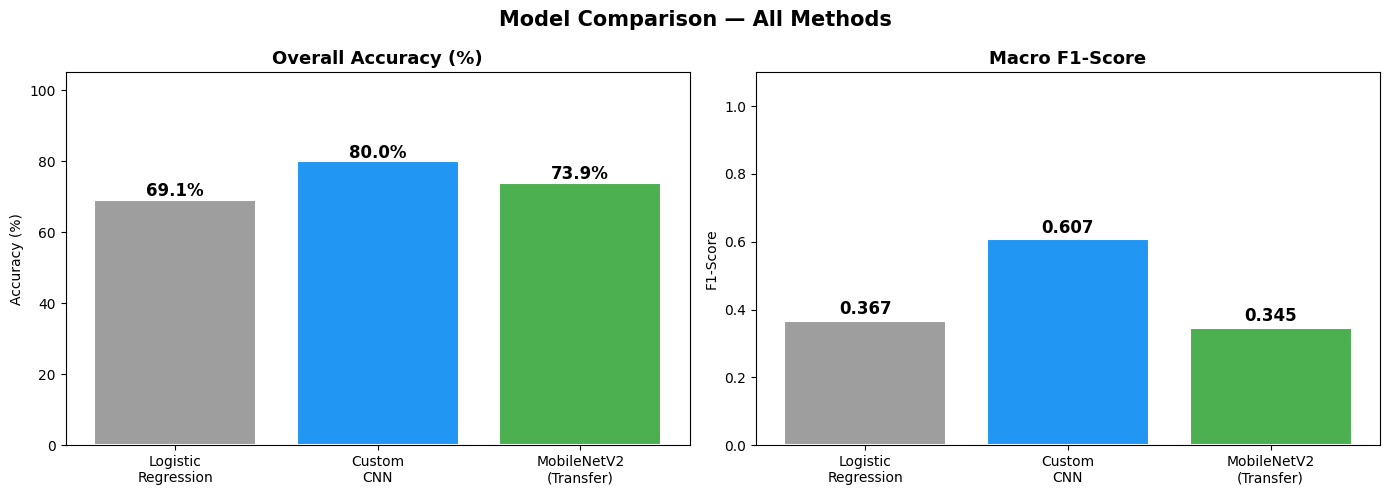

Comparison chart saved: model_comparison.png


In [27]:
# ─── Summary Comparison Table ───
comparison_data = {
    'Method': ['Logistic Regression', 'Custom CNN', 'MobileNetV2 (Transfer)'],
    'Accuracy': [f'{lr_acc*100:.1f}%', f'{cnn_results["accuracy"]*100:.1f}%', f'{mob_results["accuracy"]*100:.1f}%'],
    'Macro F1': [f'{lr_f1:.3f}', f'{cnn_results["f1"]:.3f}', f'{mob_results["f1"]:.3f}'],
    'Type': ['Baseline', 'Deep Learning (scratch)', 'Deep Learning (transfer)']
}
comp_df = pd.DataFrame(comparison_data)
print('\n FINAL COMPARISON:')
print(comp_df.to_string(index=False))

# Comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison — All Methods', fontsize=15, fontweight='bold')

methods = ['Logistic\nRegression', 'Custom\nCNN', 'MobileNetV2\n(Transfer)']
accuracies = [lr_acc * 100, cnn_results['accuracy'] * 100, mob_results['accuracy'] * 100]
f1_scores = [lr_f1, cnn_results['f1'], mob_results['f1']]
colors = ['#9E9E9E', '#2196F3', '#4CAF50']

bars1 = axes[0].bar(methods, accuracies, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Overall Accuracy (%)', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 105)
axes[0].set_ylabel('Accuracy (%)')
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

bars2 = axes[1].bar(methods, f1_scores, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Macro F1-Score', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('F1-Score')
for bar, val in zip(bars2, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Comparison chart saved: model_comparison.png')

##  9. Save Models & Export

In [29]:
# Save models
cnn_model.save('custom_cnn_final.keras')
mob_model.save('mobilenetv2_final.keras')
print('Models saved!')

# Download key outputs
from google.colab import files

outputs_to_download = [
    'class_distribution.png',
    'sample_images.png',
    'cnn_learning_curves.png',
    'mobilenet_learning_curves.png',
    'confusion_matrix_custom_cnn.png',
    'confusion_matrix_mobilenetv2.png',
    'model_comparison.png',
]

print('\nDownloading output files...')
for f in outputs_to_download:
    if os.path.exists(f):
        files.download(f)
        print(f'  ✓ {f}')
    else:
        print(f'  ✗ {f} not found (may not have been generated yet)')

print('\n✅ All done!')

Models saved!



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ class_distribution.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✓ confusion_matrix_mobilenetv2.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ model_comparison.png

✅ All done!
